In [ ]:
# importing libraries
import pandas as pd
import scipy
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset
df = pd.read_csv('/content/ingredientsList_balanced_150.csv')
print(df.head())

                    name     scientific_name  \
0  myristol pentapeptide                 NaN   
1              quercetin                 NaN   
2    extract from pig 32  Pigus substance 32   
3      placental protein   placental protein   
4  stearic acid (animal)        stearic acid   

                                   short_description  \
0  Myristoyl pentapeptide is an anti-aging peptid...   
1  Quercetin is a naturally occurring bioflavonoi...   
2                      Synthetic haram ingredient 32   
3     Derived from human or animal placental tissue.   
4  Fatty acid usually derived from pork or non-ha...   

                                          what_is_it  \
0  Many peptides function as anti-ageing ingredie...   
1  Quercetin is a flavonoid, a type of plant-deri...   
2  A synthetic compound derived from porcine mate...   
3                                   Anti-aging agent   
4                              Emulsifier, thickener   

                                     

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   name                150 non-null    object
 1   scientific_name     74 non-null     object
 2   short_description   150 non-null    object
 3   what_is_it          150 non-null    object
 4   what_does_it_do     150 non-null    object
 5   who_is_it_good_for  150 non-null    object
 6   who_should_avoid    150 non-null    object
 7   url                 150 non-null    object
 8   Halal_Status        150 non-null    object
dtypes: object(9)
memory usage: 10.7+ KB


In [ ]:
#To check null values
df.isnull().sum()

,0
name,0
scientific_name,76
short_description,0
what_is_it,0
what_does_it_do,0
who_is_it_good_for,0
who_should_avoid,0
url,0
Halal_Status,0


In [ ]:
df.describe()

,name,scientific_name,short_description,what_is_it,what_does_it_do,who_is_it_good_for,who_should_avoid,url,Halal_Status
count,150,74,150,150,150,150,150,150,150
unique,150,74,150,73,76,42,16,150,2
top,myristol pentapeptide,Pigus substance 32,Myristoyl pentapeptide is an anti-aging peptid...,A synthetic compound derived from porcine mate...,Used in industrial and cosmetic applications,['General use'],"['Muslims', 'Vegetarians']",https://renude.co/ingredients/myristol-pentape...,halal
freq,1,1,1,64,64,64,64,1,75


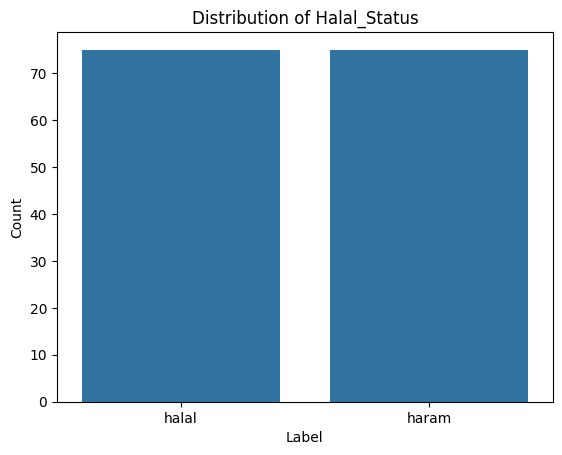

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Halal_Status', data=df)
plt.title('Distribution of Halal_Status')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


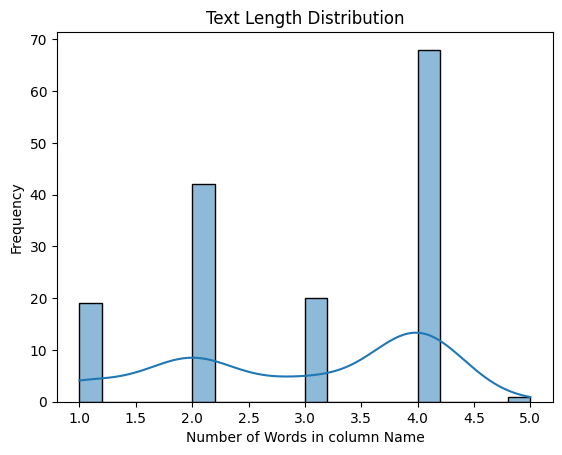

In [ ]:
df['text_length'] = df['name'].apply(lambda x: len(x.split()))

sns.histplot(df['text_length'], bins=20, kde=True)
plt.title('Text Length Distribution')
plt.xlabel('Number of Words in column Name')
plt.ylabel('Frequency')
plt.show()


In [ ]:
from collections import Counter
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def get_top_words(series, n=10):
    words = ' '.join(series).lower().split()
    filtered = [word for word in words if word.isalpha() and word not in stop_words]
    return Counter(filtered).most_common(n)

for label in df['Halal_Status'].unique():
    print(f"\nTop words for {label}:")
    print(get_top_words(df[df['Halal_Status'] == label]['name']))



Top words for halal:
[('extract', 17), ('acid', 10), ('ferment', 4), ('palmitoyl', 4), ('sulfate', 2), ('vitamin', 2), ('apple', 2), ('glycine', 2), ('oil', 2), ('lactobacillus', 2)]

Top words for haram:
[('pig', 64), ('enzyme', 15), ('essence', 15), ('alcohol', 11), ('extract', 10), ('gel', 8), ('fat', 5), ('acid', 3), ('placental', 1), ('protein', 1)]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# WORD CLOUD

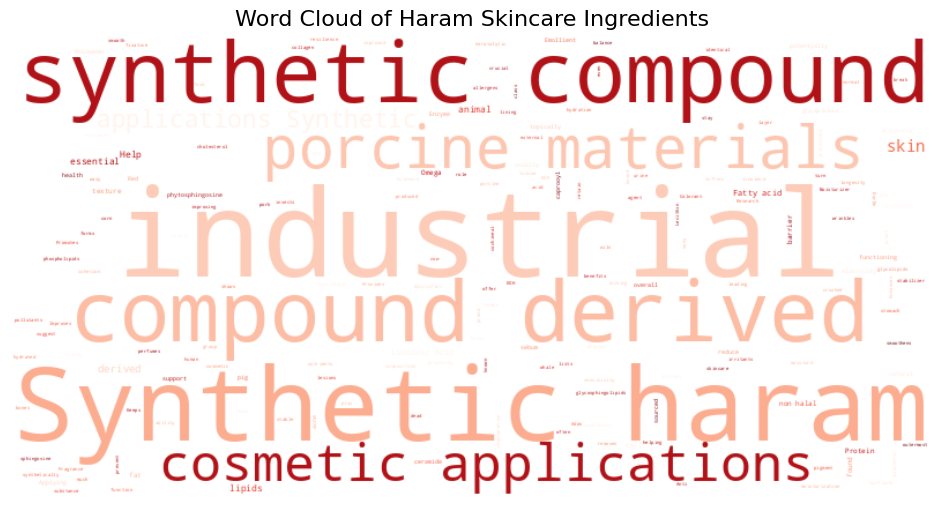

In [ ]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("ingredientsList_balanced_150.csv")

# Filter only haram ingredients
haram_df = df[df["Halal_Status"].str.lower() == "haram"]

# Combine relevant text columns
text_columns = ['short_description', 'what_is_it', 'what_does_it_do']
combined_text = haram_df[text_columns].fillna('').agg(' '.join, axis=1).str.cat(sep=' ')

# Define stopwords
stopwords = set(STOPWORDS)
stopwords.update(['used', 'ingredient', 'ingredients', 'used', 'product', 'products', 'may'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      stopwords=stopwords, colormap='Reds').generate(combined_text)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Haram Skincare Ingredients", fontsize=16)
plt.show()


# **SENTIMENT ANALYSIS: HARAM DETECTION**

**Import Libraries**

In [ ]:
import pandas as pd
import re
import string
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from nltk.corpus import stopwords
import nltk
import numpy as np
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

This section imports essential libraries for data manipulation, splitting datasets, text processing, building models, and evaluating performance.

**Load the Dataset**

In [ ]:
file_path = 'ingredientsList_balanced_150.csv'
df = pd.read_csv(file_path)

<p style ="font-size:15px">The dataset is loaded using pandas, and basic exploration functions are used to display the structure, summary, and distribution of emotions.</p>

**Data Preprocessing**

In [ ]:
# Preprocessing function for ingredient descriptions
def preprocess_ingredients(text):
    if pd.isna(text):
        return ""
    text = text.lower()  # Lowercase
    text = re.sub(f"[{string.punctuation}]", "", text)  # Remove punctuation
    text = re.sub(r"\d+", "", text)  # Remove numbers
    stop_words = set(stopwords.words('english'))
    text = " ".join([word for word in text.split() if word not in stop_words])  # Remove stop words
    return text

# Apply preprocessing to the 'what_is_it' column
df['cleaned_text'] = df['what_is_it'].apply(preprocess_ingredients)

# Preview result
print(df[['what_is_it', 'cleaned_text', 'Halal_Status']].head())


                                          what_is_it  \
0  Many peptides function as anti-ageing ingredie...   
1  Quercetin is a flavonoid, a type of plant-deri...   
2  A synthetic compound derived from porcine mate...   
3                                   Anti-aging agent   
4                              Emulsifier, thickener   

                                        cleaned_text Halal_Status  
0  many peptides function antiageing ingredients ...        halal  
1  quercetin flavonoid type plantderived compound...        halal  
2       synthetic compound derived porcine materials        haram  
3                                    antiaging agent        haram  
4                               emulsifier thickener        haram  


**Train-Test Split**

In [ ]:
# Features and labels
X = df['cleaned_text']
y = df['Halal_Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


The dataset is split into training and testing sets. cleaned_text contains the input text, while Halal_status serves as target labels.

**TF-IDF + Logistic Regression**

In [ ]:
# TF-IDF + Logistic Regression pipeline (with built-in English stopwords)
model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000))
])

# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

       halal       0.85      1.00      0.92        17
       haram       1.00      0.77      0.87        13

    accuracy                           0.90        30
   macro avg       0.93      0.88      0.89        30
weighted avg       0.91      0.90      0.90        30



**Percentage of Halal and Haram Labels**

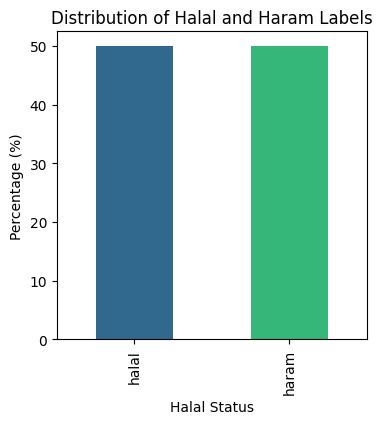

Percentage of each class in 'division':
halal: 50.00%
haram: 50.00%


In [ ]:
import seaborn as sns

# Calculate percentage distribution
class_percentages = df['Halal_Status'].value_counts(normalize=True) * 100

# Set aesthetic color palette
palette = sns.color_palette("viridis", len(class_percentages))

# Plot the bar chart with custom colors
class_percentages.plot(kind="bar", color=palette, legend=False, fontsize=10, figsize=(4, 4))

plt.title('Distribution of Halal and Haram Labels')
plt.xlabel('Halal Status')
plt.ylabel('Percentage (%)')
plt.show()

# Print percentage values for each class
print("Percentage of each class in 'division':")
for class_label, percentage in class_percentages.items():
    print(f"{class_label}: {percentage:.2f}%")



**Feature Selection and Model Pipelines**

Logistic Regression Cross-validation accuracy: 0.9267
Naive Bayes Cross-validation accuracy: 0.9533

Logistic Regression - Accuracy on Test Set: 0.9

Logistic Regression - Classification Report:
               precision    recall  f1-score   support

       halal       0.85      1.00      0.92        17
       haram       1.00      0.77      0.87        13

    accuracy                           0.90        30
   macro avg       0.93      0.88      0.89        30
weighted avg       0.91      0.90      0.90        30


Naive Bayes - Accuracy on Test Set: 1.0

Naive Bayes - Classification Report:
               precision    recall  f1-score   support

       halal       1.00      1.00      1.00        17
       haram       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



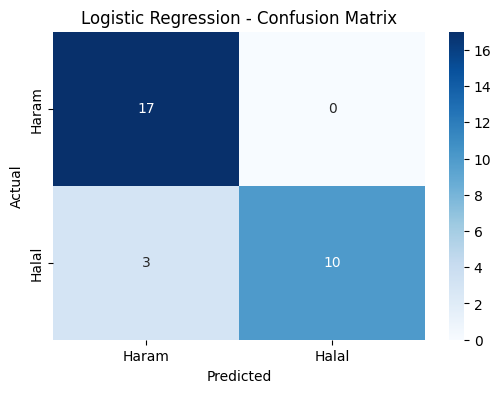

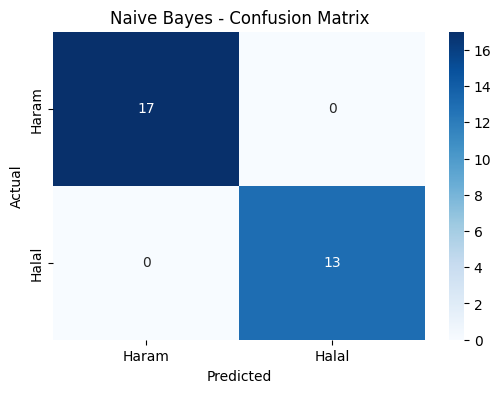

In [ ]:
# Preprocessing function
def preprocess_ingredients(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r"\d+", "", text)
    return text

# Apply preprocessing
df['cleaned_text'] = df['what_is_it'].apply(preprocess_ingredients)

# Features and target
X = df['cleaned_text']
y = df['Halal_Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression Pipeline
logreg_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Naive Bayes Pipeline
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('classifier', MultinomialNB())
])

# Cross-validation for both models
logreg_cv_scores = cross_val_score(logreg_pipeline, X, y, cv=5, scoring='accuracy')
nb_cv_scores = cross_val_score(nb_pipeline, X, y, cv=5, scoring='accuracy')

# Print cross-validation scores for both models
print(f"Logistic Regression Cross-validation accuracy: {logreg_cv_scores.mean():.4f}")
print(f"Naive Bayes Cross-validation accuracy: {nb_cv_scores.mean():.4f}")

# Fit both models with the training data
logreg_pipeline.fit(X_train, y_train)
nb_pipeline.fit(X_train, y_train)

# Predict on test set for both models
logreg_pred = logreg_pipeline.predict(X_test)
nb_pred = nb_pipeline.predict(X_test)

# Evaluation for Logistic Regression
print("\nLogistic Regression - Accuracy on Test Set:", accuracy_score(y_test, logreg_pred))
print("\nLogistic Regression - Classification Report:\n", classification_report(y_test, logreg_pred))

# Evaluation for Naive Bayes
print("\nNaive Bayes - Accuracy on Test Set:", accuracy_score(y_test, nb_pred))
print("\nNaive Bayes - Classification Report:\n", classification_report(y_test, nb_pred))

# Import confusion_matrix
from sklearn.metrics import confusion_matrix # Importing the missing function

# Confusion Matrix for Logistic Regression
logreg_cm = confusion_matrix(y_test, logreg_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(logreg_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Haram", "Halal"], yticklabels=["Haram", "Halal"])
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Confusion Matrix for Naive Bayes
nb_cm = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(nb_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Haram", "Halal"], yticklabels=["Haram", "Halal"])
plt.title('Naive Bayes - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


**Visualization: Accuracy Comparison**

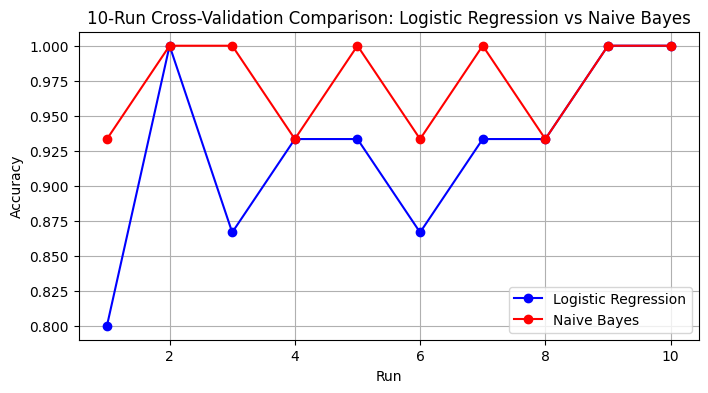

In [ ]:
# Cross-validation for both models (Logistic Regression and Naive Bayes)
logreg_cv_scores = cross_val_score(logreg_pipeline, X, y, cv=10, scoring='accuracy')
nb_cv_scores = cross_val_score(nb_pipeline, X, y, cv=10, scoring='accuracy')

# Ensure the number of runs matches the length of the scores
num_runs = len(logreg_cv_scores)  # This will be 10 if cv=10

# Plotting the comparison of 10-run cross-validation accuracy scores
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_runs + 1), logreg_cv_scores, marker='o', color='blue', label='Logistic Regression')
plt.plot(range(1, num_runs + 1), nb_cv_scores, marker='o', color='red', label='Naive Bayes')
plt.xlabel('Run')
plt.ylabel('Accuracy')
plt.title('10-Run Cross-Validation Comparison: Logistic Regression vs Naive Bayes')
plt.legend()
plt.grid(True)
plt.show()


**Model Training and Evaluation**

In [ ]:
# Define the Naive Bayes pipeline
nb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('classifier', MultinomialNB())
])

# Define the SVM pipeline
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('classifier', SVC(kernel='linear'))
])

# Example training and test data (replace these with your actual data)
X = df['cleaned_text']  # Feature (text)
y = df['Halal_Status']  # Target label

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and evaluate Naive Bayes model
nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)

# Evaluate Naive Bayes model
print("\nNaive Bayes Model Evaluation:")
print("Test Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

# Train and evaluate SVM model
svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)

# Evaluate SVM model
print("\nSVM Model Evaluation:")
print("Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))



Naive Bayes Model Evaluation:
Test Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

       halal       1.00      1.00      1.00        17
       haram       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


SVM Model Evaluation:
Test Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

       halal       0.85      1.00      0.92        17
       haram       1.00      0.77      0.87        13

    accuracy                           0.90        30
   macro avg       0.93      0.88      0.89        30
weighted avg       0.91      0.90      0.90        30



**Real-Time Sentiment and Emotion Detection**

In [ ]:
# Sample lexicons
haram_ingredients = [
    'gelatin', 'alcohol', 'lard', 'enzymes from pig', 'carmine', 'pepsin',
    'pig', 'pork', 'gel from pig', 'extract from pig', 'animal derived'
]

doubtful_ingredients = [
    'emulsifier', 'fragrance', 'flavor', 'colorant', 'e-number', 'animal'
]

doubtful_ingredients = ['emulsifier', 'fragrance', 'flavor', 'colorant', 'e-number']

def preprocess_text(text):
    # Lowercase, remove special characters
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9,\s]', '', text)
    return text.split(',')

def detect_halal_status(ingredients_list):
    processed = preprocess_text(ingredients_list)

    status = 'halal'
    reasons = []

    for ingredient in processed:
        ingredient = ingredient.strip()
        if any(haram in ingredient for haram in haram_ingredients):
            status = 'haram'
            reasons.append(ingredient)
        elif status != 'haram' and any(doubt in ingredient for doubt in doubtful_ingredients):
            status = 'doubtful'
            reasons.append(ingredient)

    print(f"Ingredients: {processed}")
    print(f"Status: {status.upper()}")
    if reasons:
        print(f"Reason(s): {', '.join(reasons)}")
    print("-" * 40)

# Apply detection to each row
for index, row in df.iterrows():
    print(f"Product #{index+1}")
    detect_halal_status(row['name'])  # adjust column name if needed


Product #1
Ingredients: ['myristol pentapeptide']
Status: HALAL
----------------------------------------
Product #2
Ingredients: ['quercetin']
Status: HALAL
----------------------------------------
Product #3
Ingredients: ['extract from pig 32']
Status: HARAM
Reason(s): extract from pig 32
----------------------------------------
Product #4
Ingredients: ['placental protein']
Status: HALAL
----------------------------------------
Product #5
Ingredients: ['stearic acid animal']
Status: HALAL
----------------------------------------
Product #6
Ingredients: ['zinc sulfate']
Status: HALAL
----------------------------------------
Product #7
Ingredients: ['macrocystis pyrifera kelp extract']
Status: HALAL
----------------------------------------
Product #8
Ingredients: ['gel from pig 55']
Status: HARAM
Reason(s): gel from pig 55
----------------------------------------
Product #9
Ingredients: ['lascorbic acid']
Status: HALAL
----------------------------------------
Product #10
Ingredients: ['